c:\Users\Hashir\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyrtools\pyramids\SteerablePyramidFreq.py:87: UserWarning: Reconstruction will not be perfect with odd-sized images
  warnings.warn("Reconstruction will not be perfect with odd-sized images")


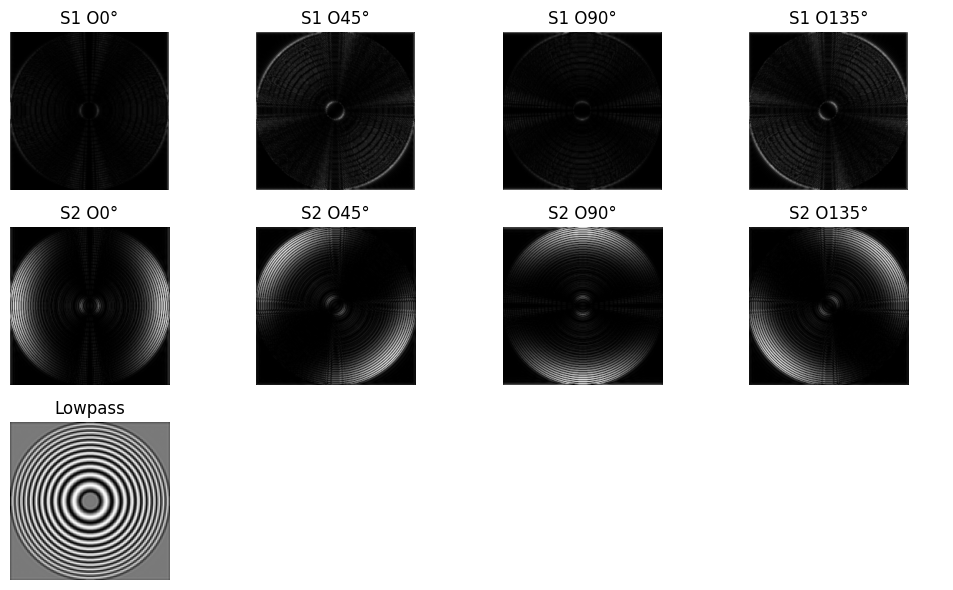

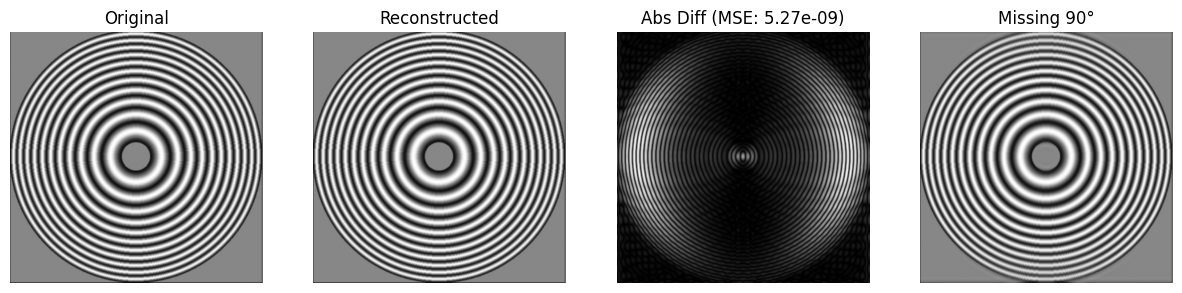

Reconstruction MSE: 5.274954425181851e-09


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyrtools as pt
from skimage import io, color

img = io.imread("img.png", as_gray=True).astype(np.float32)
img = (img - img.min()) / (img.max() - img.min())
H, O = 2, 4  # 2 Scales, 4 Orientations
pyr = pt.pyramids.SteerablePyramidFreq(img, height=H, order=O-1)

# 2. Visualize Sub-bands & Lowpass
fig, axes = plt.subplots(H + 1, O, figsize=(10, 6))
for s in range(H):
    for o in range(O):
        axes[s, o].imshow(np.abs(pyr.pyr_coeffs[(s, o)]), cmap='gray')
        axes[s, o].set_title(f"S{s+1} O{o*45}°")
axes[H, 0].imshow(pyr.pyr_coeffs['residual_lowpass'], cmap='gray')
axes[H, 0].set_title("Lowpass")
[ax.axis('off') for ax in axes.ravel()]
plt.tight_layout()

# 3. Reconstruction & Error Analysis
recon = np.clip(pyr.recon_pyr(), 0, 1)
mse = np.mean((img - recon)**2)
diff = np.abs(img - recon)

# 4. Remove 90° Orientation (Index 2) and Reconstruct
mod_pyr = pt.pyramids.SteerablePyramidFreq(img, height=H, order=O-1)
for s in range(H): 
    mod_pyr.pyr_coeffs[(s, 2)] = np.zeros_like(mod_pyr.pyr_coeffs[(s, 2)])
recon_m = np.clip(mod_pyr.recon_pyr(), 0, 1)

titles = ["Original", "Reconstructed", "Abs Diff (MSE: {:.2e})".format(mse), "Missing 90°"]
images = [img, recon, diff, recon_m]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap='gray' if 'Diff' not in t else 'gray')
    ax.set_title(t)
    ax.axis('off')

plt.show()
print(f"Reconstruction MSE: {mse}")

In [ ]:
# ==========================================================
# CNN CLASSIFIER FOR JPEG DETECTION USING FFT RESIDUALS
# ==========================================================

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ==========================================================
# 1. PARAMETERS
# ==========================================================

DATASET_PATH = "dataset"
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# 2. RESIDUAL + FFT FEATURE EXTRACTION
# ==========================================================

def compute_residual(img):
    # High-pass residual using Laplacian
    residual = cv2.Laplacian(img, cv2.CV_32F)
    return residual

def compute_fft_magnitude(residual):
    fft = np.fft.fft2(residual)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log(np.abs(fft_shift) + 1)
    return magnitude

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0

    residual = compute_residual(img)
    fft_mag = compute_fft_magnitude(residual)

    # Normalize FFT image
    fft_mag = (fft_mag - fft_mag.min()) / (fft_mag.max() - fft_mag.min() + 1e-8)

    return fft_mag

# ==========================================================
# 3. LOAD DATA
# ==========================================================

X = []
y = []

for label, folder in enumerate(["original", "compressed"]):
    folder_path = os.path.join(DATASET_PATH, folder)
    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)
        feature = preprocess_image(path)
        X.append(feature)
        y.append(label)

X = np.array(X)
y = np.array(y)

# Add channel dimension
X = np.expand_dims(X, axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================================
# 4. PYTORCH DATASET
# ==========================================================

class FFTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(FFTDataset(X_train, y_train),
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(FFTDataset(X_test, y_test),
                         batch_size=BATCH_SIZE,
                         shuffle=False)

# ==========================================================
# 5. SIMPLE CNN MODEL
# ==========================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE//8) * (IMG_SIZE//8), 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(DEVICE)

# ==========================================================
# 6. TRAINING SETUP
# ==========================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================================
# 7. TRAINING LOOP (5 EPOCHS)
# ==========================================================

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

# ==========================================================
# 8. TEST EVALUATION
# ==========================================================

model.eval()
all_preds = []
all_labels = []
test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
accuracy = accuracy_score(all_labels, all_preds)

print("\n===== TEST RESULTS =====")
print("Test Loss:", round(avg_test_loss, 4))
print("Test Accuracy:", round(accuracy * 100, 2), "%")